# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [141]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [143]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [144]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [145]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [146]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [147]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [148]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [149]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [187]:
# cantidad de nulos para users
miss_users = users.isna().sum()
proporcion_users = users.isna().mean() * 100
print('Cantidad de valores nulos:', miss_users)
print('Proporción de valores nulos:', proporcion_users)

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          14.125
reg_date       1.000
plan           0.000
churn_date    88.350
dtype: float64


In [186]:
# cantidad de nulos para usage
miss_usage = usage.isna().sum()
proporcion_usage = usage.isna().mean() * 100
print('Cantidad de valores nulos:', miss_usage)
print('Proporción de valores nulos:', proporcion_usage)

Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration        0
length      17896
is_text         0
is_call         0
dtype: int64
Proporción de valores nulos: id           0.000
user_id      0.000
type         0.000
date         0.125
duration     0.000
length      44.740
is_text      0.000
is_call      0.000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- City y churn_date 
- Indica qué harías: ¿imputar, eliminar, ignorar?
- en el caso de city imputaria, pero en el caso de churn_date los eliminiaria para que no contaminaran los datos

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [152]:
# explorar columnas numéricas de users
users.describe().round(0)

,user_id,age
count,4000.0,4000.0
mean,12000.0,34.0
std,1155.0,123.0
min,10000.0,-999.0
25%,11000.0,32.0
50%,12000.0,47.0
75%,12999.0,63.0
max,13999.0,79.0


- La columna `user_id` los datos de user_id, concuerdan con el numero total de edades registradas, por lo que se podria entender que esta completa
- La columna `age` por otro lado tenemos valores atipicos, como el valor minimo de edad '-999'

In [153]:
# explorar columnas numéricas de usage
usage.describe().round(0)

,id,user_id,duration,length
count,40000.0,40000.0,17924.0,22104.0
mean,20000.0,12002.0,5.0,52.0
std,11547.0,1157.0,7.0,57.0
min,1.0,10000.0,0.0,0.0
25%,10001.0,10996.0,1.0,37.0
50%,20000.0,12013.0,4.0,50.0
75%,30000.0,13005.0,7.0,64.0
max,40000.0,13999.0,120.0,1490.0


- Las columnas `id` y `user_id` tenemos el mismo numero de datos en ambos
- Las columnas `duration` y ` length` faltan de varios datos ya que la meta serian `40000` y llegan apenas a la mitad de los datos

In [154]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` existen menos registros de los esperados y cuenta con 7 valores unicos
- La columna `plan` los datos registrados estan completos y cuenta con 2 datos unicos

In [155]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con todos los datos requeridos con 2 valores unicos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En el dataset de users, hay falta de datos en la columna 'city' y en la columna age con datos negativos como '-999'
- En el dataset de usage, hay falta de datos en 'length' y 'duration'
- ¿Qué acción tomarías?
- En ambos data sets haria una imputacion en ambos casos para tener una menor perdida de datos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [156]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce')

In [157]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce')

In [158]:
# Revisar los años presentes en `reg_date` de users
años_user = users['reg_date'].dt.year.unique()
print('Años presentes:', años_user)

Años presentes: [2022 2026 2023 2024]


En `reg_date`, se ve que tenemos años 2022, 23, 24 y 26

In [159]:
# Revisar los años presentes en `date` de usage
años_usage = usage['date'].dt.year.unique()
print('Años presentes:', años_usage)

Años presentes: [2024.   nan]


En `date`, solo cuenta con 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- vienen años imposibles como 2026
- ¿Qué harías con ellas?
- hacer imputación a fechas cercanas

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [160]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].isna().sum()

0

In [161]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
ver = (users['city'] == '?').sum()
print(ver)

0


In [162]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan
# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [163]:
# Verificación MAR en usage (Missing At Random) para duration
duration_missing_type = (usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False))*100
print("Proporcion de nulos en 'duration' por type")
print(duration_missing_type)

Proporcion de nulos en 'duration' por type
type
text    99.927576
call     0.000000
Name: duration, dtype: float64


In [164]:
# Verificación MAR en usage (Missing At Random) para length
length_missing_type = (usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False))*100
print("Proporcion de nulos en 'length' por type")
print(length_missing_type)

Proporcion de nulos en 'length' por type
type
call    99.932991
text     0.000000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

debido a los resultados de un 99.9% en ambos casos de nulos, se entiende que es un caso MAR, por lo tanto no son nulos aleatorios si no que dependen directamente de la columna 'type', esto en ambas columnas, tanto 'length' como 'duration'

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [165]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Transformar los nulos de la duracion a 0
usage['duration'] = usage['duration'].fillna(0)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',    #Total de menssajes
    'is_call': 'sum',    #Total de llamadas
    'duration': 'sum'    #Total de minutos
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [166]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text':'cant_mensajes', 
    'is_call':'cant_llamadas', 
    'duration':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [167]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [168]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [169]:
# Distribución porcentual del tipo de plan
porcentual = (users['plan'].value_counts(normalize=True))*100
print(porcentual)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

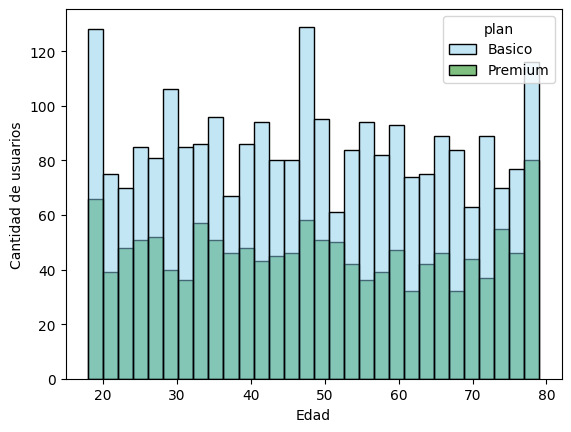

In [170]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=30

    #Quise porner los bin con la formula de los mismos, pero se pierde el enfoque del histograma al ser tantos datos y con un bin menor siento que hay mejores rango de visualizacion para el usuario
)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Se puede observar que tiene una distribucion uniforme o plana, ya que no hay una tendencia de picos de datos hacia ningún extremo, dandonos a entender que hay una pequeña 'uniformidad' en los datos

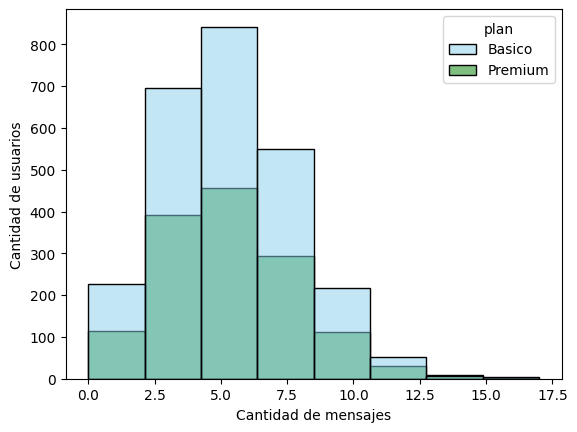

In [171]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins = 8
)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- En este histograma claramente es un sesgo a la derecha en ambos planes, ya que la cantidad de mensajes cuando aumentan menos cantidad de usuarios los usan llgando casi a 0

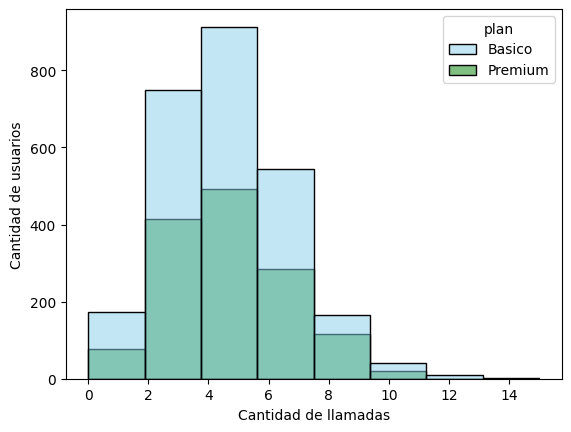

In [172]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=8
)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Ladistribución al igual que el de cantidad de mensajes es con sesgo a la derecha, aun con menos usuarios haciendo uso de llamadas

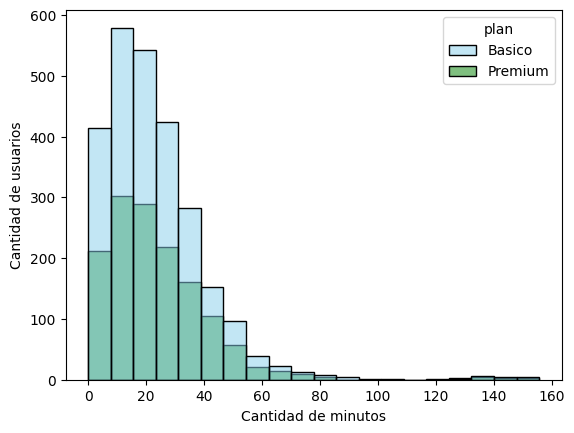

In [173]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)
plt.xlabel('Cantidad de minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución de sesgo a la derecha ya que hay una gran acumulación de datos del lado izquierdo, mientras que del otro no se encuentran casi nada de datos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

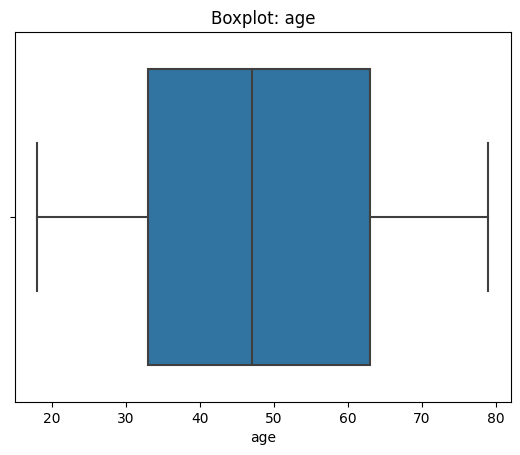

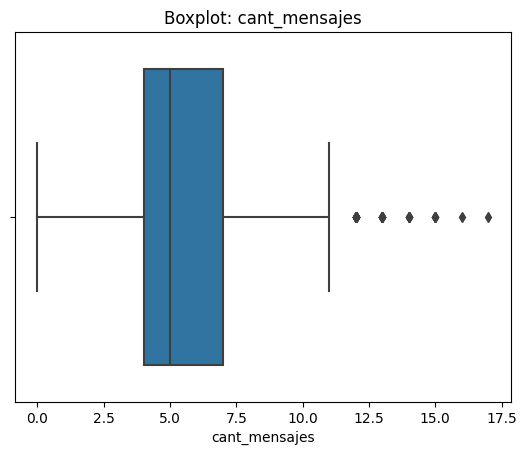

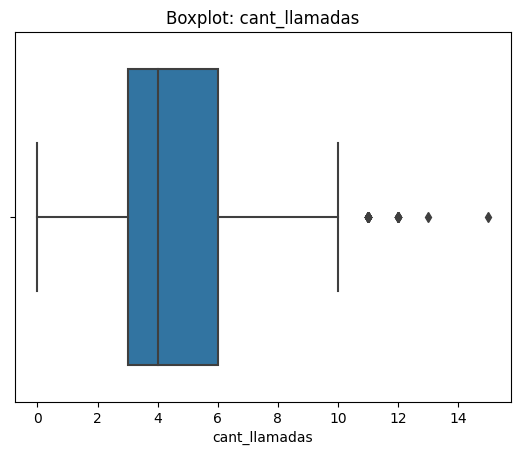

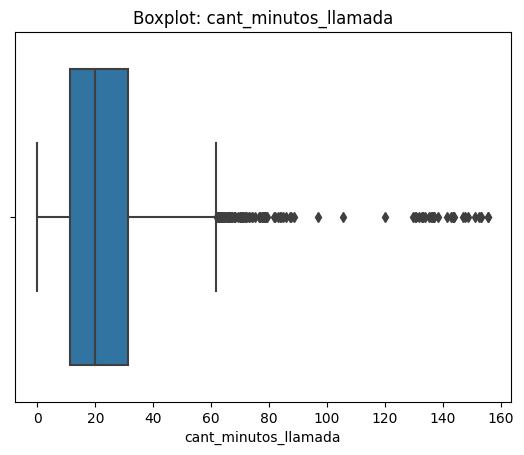

In [174]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    # 1. Crear gráfico
    sns.boxplot(x=user_profile[col])

    # 2. Se agregan titulos, mediante el FOR
    plt.title(f'Boxplot: {col}')
    plt.show() 


💡Insights: 
- Age: no presenta outliers
- cant_mensajes: si presenta outliers
- cant_llamadas: si presenta outliers
- cant_minutos_llamada: presenta demasiados outliers

In [175]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for len in columnas_limites:
    # Se calulan Q3, Q1 y IQR
    Q3 = user_profile[len].quantile(0.75)
    Q1 = user_profile[len].quantile(0.25)
    IQR = Q3 - Q1
    # Se calcula el limite superior e inferior
    limite_sup = Q3 + (1.5 * IQR)
    limite_inf = Q1 - (1.5 * IQR)
    print(f'IQR de {len} es:', IQR)
    print(f'Limite superior de {len} es:',limite_sup.round(2))
    print(f'Limite inferior de {len} es:',limite_inf.round(2))
    print('=' * 50)



IQR de cant_mensajes es: 3.0
Limite superior de cant_mensajes es: 11.5
Limite inferior de cant_mensajes es: -0.5
IQR de cant_llamadas es: 3.0
Limite superior de cant_llamadas es: 10.5
Limite inferior de cant_llamadas es: -1.5
IQR de cant_minutos_llamada es: 20.295
Limite superior de cant_minutos_llamada es: 61.86
Limite inferior de cant_minutos_llamada es: -19.32


In [176]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- no los mantendria debido a que son muy pocos datos
- cant_llamadas: mantener o no outliers, porqué?
- no los mantendria debido a que son muy pocos datos
- cant_minutos_llamada: mantener o no outliers, porqué?
- mantendria los datos, haciendo clapping, y manteniendo los datos en el limite superior, debido a que habria una gran sesgo
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [177]:

# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), # Condicion baja
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), # Condicion alta
]
uso = ['Bajo', 'Uso medio'] # Valores a tomar dependiendo la condicion
user_profile['grupo_uso'] = np.select(condiciones, uso, default = 'Alto') # Creacion de la columna y ajustando que cualquier valor fuera de las condiciones pasadas sean 'Alto'


In [178]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [179]:
# Crear columna grupo_edad
con_edad = [
    (user_profile['age'] < 30) & (user_profile['age'] < 30), # Condicion joven
    (user_profile['age'] < 60) & (user_profile['age'] < 60), # Condicion alta
]

# Valores a tomar dependiendo la condicion
uso_edad = ['Joven', 'Adulto'] 
# Creacion de la columna y ajustando que cualquier valor fuera de las condiciones pasadas sean 'Adulto Mayor'
user_profile['grupo_edad'] = np.select(con_edad, uso_edad, default = 'Adulto Mayor') 

In [189]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

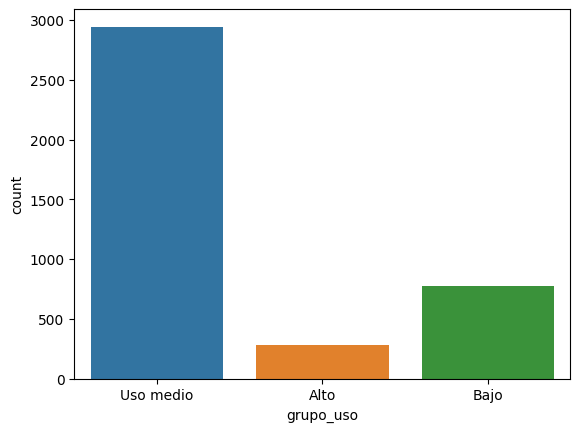

In [181]:
# Visualización de los segmentos por uso
sns.countplot(x = user_profile['grupo_uso'])
plt.show()

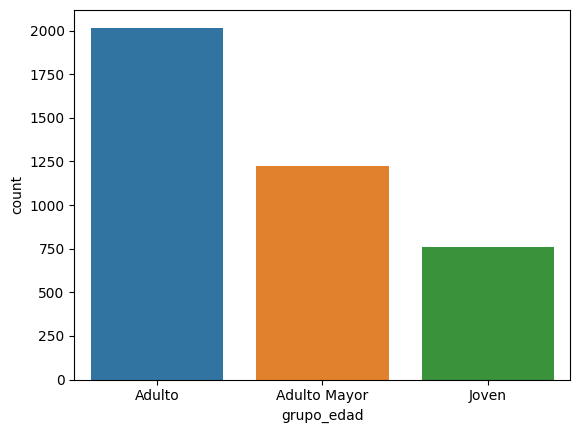

In [182]:
# Visualización de los segmentos por edad
sns.countplot(x = user_profile['grupo_edad'])
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ 
Originalmente ambos dataset (users & usage) tienen varios valores nulos: 
- El dataset de users tiene varios valores nulos tanto en ‘city’ como en ‘churn_date’ y ‘reg_date , ‘city’ representando el 14.12% de los datos nulos, en ‘churn_date’ el 88.35% y en ‘reg_date’ el 1%.
- El dataset de usage tiene valores nulos en ‘date’ y ‘length’, ‘date’ teniendo datos nulos en 0.125% y ‘length’ tiene el 44.74%.

En un principio identificó que los Adultos son los que mayormente tienen un nivel de uso alto y medio, los adultos mayores tienen una mayor inclinación hacia un uso medio y los jóvenes tienen un uso bajo.
Con estos datos los mejores segmentos parecen ser los adultos y la cantidad y duración de llamadas que tienen ya que el grupo de edad de adultos son los que mayor uso le dan y la cantidad de llamadas a pesar de ser menores que los mensajes, pero a pesar de esto la duración de llamadas son largas, con lo cual podrían sacar más provecho de esa longitud de llamadas.

En cuanto a outliers encontrados el más grande que hay es el de cantidad de minutos, como se ve en el boxplot del mismo tenemos demasiados outliers de 60 min en adelante en duración de llamadas lo cual implica que hay un sesgo de datos muy amplio, ya que se puede considerar que realmente es raro, que alguien hable más de ese tiempo por llamada, aunque no imposible, por lo cual el negocio podría estar teniendo una pérdida dándole más importancia a mensajes que al costo de llamadas.

Como recomendación se daría que los planes premium les ofrecieran un poco más en las llamadas llamando así la atención de más clientes y teniendo un posible incremento en el uso, aunque los mensajes también no deberían dejarse de lado, ya que aportan una buena cantidad de usuarios en su uso.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Nulos en data sets
- Fechas en tipo numérico en vez de fecha



🔍 **Segmentos por Edad**
- Adultos  
- Jóvenes 
- Adultos Mayores



📊 **Segmentos por Nivel de Uso**
- Uso medio
- Alto
- Bajo


➡️ Esto sugiere que: Los Adultos son lo que mayor cantidad de tiempo usan el plan, en continuación son los Adultos Mayores y los Jóvenes son los que menos uso le dan.


💡 **Recomendaciones**
- Mantener o mejorar un poco la oferta de los planes para los adultos
- Mejorar los costos o publicidad llegando a intentar adquirir más gente joven en sus planes
- Aumentar el atractivo en llamadas, considerando que posiblemente los outliers no sean errores y realmente sea un atractivo para alguno de los grupos de edad considerados


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`